# Mean Shift

Implementacion basica del algoritmo Mean Shift utilizando el siguiente conjunto de datos

In [28]:
import pandas as pd
from sklearn.cluster import MeanShift, estimate_bandwidth 
import matplotlib.pyplot as plt
import numpy as np

In [29]:
compras = (
    9000, 12000, 14000, 17500, 20000, 22500, 24500, 25500, 27000, 28500,
    30500, 33000, 36500, 37500, 40500, 43500, 45500, 48000, 50000, 52000, 54000
)

movimientos = (
    8, 4, 9, 7, 18, 9, 4, 23, 18, 26, 19, 24, 13, 9, 12, 6, 9, 10, 9, 13, 14
)
print(f"total de registros: {len(compras)} montos y {len(movimientos)} movimientos")

total de registros: 21 montos y 21 movimientos


In [30]:
clientes = pd.DataFrame({"compras": compras, "movimientos": movimientos})
clientes.head()

,compras,movimientos
0,9000,8
1,12000,4
2,14000,9
3,17500,7
4,20000,18


In [31]:
clientes_movimientos = np.column_stack((clientes,movimientos))

In [32]:
#Determinar el tamaño de bandwith
bandwidth = estimate_bandwidth(clientes_movimientos, quantile=0.3, n_samples=len(clientes_movimientos))
print(f"Ancho de banda calculado: {bandwidth}")

Ancho de banda calculado: 7000.0065362533305


In [33]:
#modelo con MeanShift
ms_clientes_movimientos = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_clientes_movimientos.fit(clientes_movimientos)

MeanShift(bandwidth=7000.0065362533305, bin_seeding=True)

In [34]:
label_clientes_movimientos = ms_clientes_movimientos.labels_
cluster_centroides = ms_clientes_movimientos.cluster_centers_
print(label_clientes_movimientos)
print(cluster_centroides)

[3 3 3 3 3 0 0 0 0 0 0 2 2 2 2 1 1 1 1 1 1]
[[2.73571429e+04 1.75714286e+01 1.75714286e+01]
 [4.88333333e+04 1.01666667e+01 1.01666667e+01]
 [3.44166667e+04 1.71666667e+01 1.71666667e+01]
 [1.45000000e+04 9.20000000e+00 9.20000000e+00]]


In [35]:
#Identficacion de clusters
n_clusters = len(np.unique(label_clientes_movimientos))
print(f"Numero de clusters: {n_clusters}")

Numero de clusters: 4


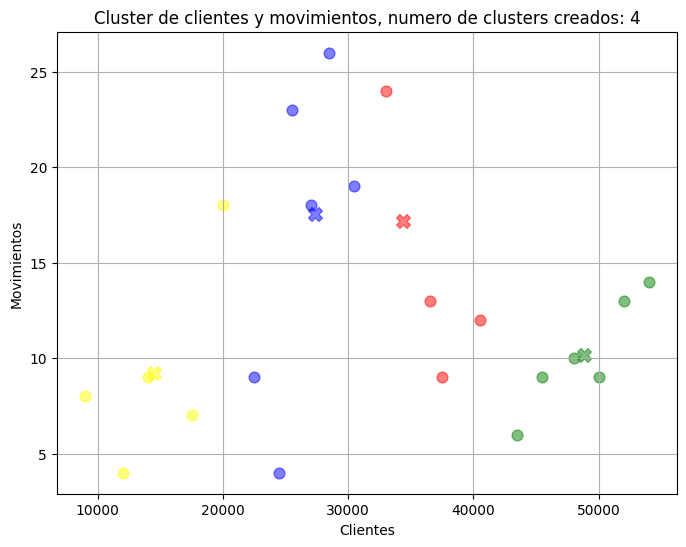

In [42]:
#Visualizacion de los clusters y centroides
plt.figure(figsize=(8,6))
#catalogo de colores
colores = ['blue', 'green', 'red', 'yellow', 'brown', 'pink', 'purple']
# graficando cada cluster
for i in range(n_clusters):
    # puntos de cluster
    cluster_member = label_clientes_movimientos == i
    cluster_centro =  cluster_centroides[i]
    #puntos scatter
    plt.scatter(
        clientes_movimientos[cluster_member, 0],
        clientes_movimientos[cluster_member, 1],
        color=colores[i], 
        s=60, 
        label=f"centro del cluster {i}",
        alpha=0.5)
    #centroides
    plt.scatter(
        cluster_centro[0],
        cluster_centro[1],
        color=colores[i], marker="X",
        s=100,
        label=f"centroide del cluster {i}",
        alpha=0.5)
plt.title(f"Cluster de clientes y movimientos, numero de clusters creados: {n_clusters}")
plt.xlabel("Clientes")
plt.ylabel("Movimientos")
plt.grid(True)
plt.show()